In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
df = pd.read_csv('Wine dataset.csv')

In [26]:
df.head()

,class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


<Axes: xlabel='Alcohol', ylabel='Density'>

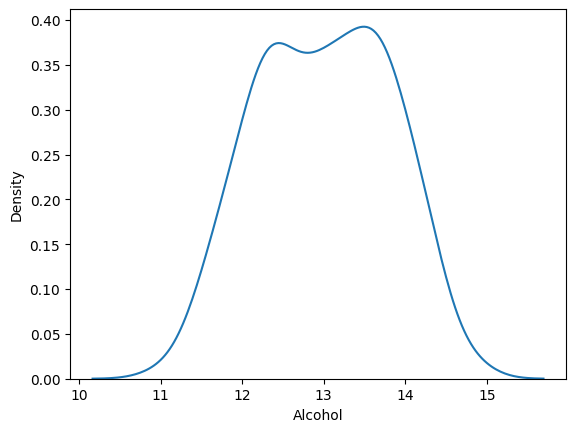

In [27]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Malic acid', ylabel='Density'>

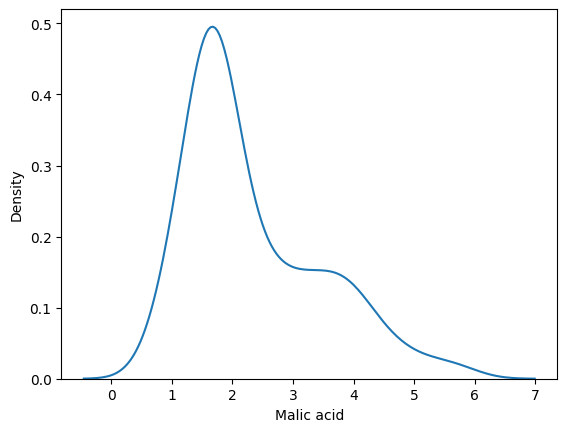

In [28]:
sns.kdeplot(df['Malic acid'])

In [29]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('class',axis = 1),
                                                    df['class'],
                                                    test_size=0.3,
                                                    random_state=0)
X_train.shape, X_test.shape

((124, 13), (54, 13))

In [30]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [33]:
np.round(X_train.describe(),1)

,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
count,124.0,124.0,124.0,124.0,124.0,124.0,124.0,124.0,124.0,124.0,124.0,124.0,124.0
mean,13.0,2.4,2.4,19.5,100.1,2.3,2.0,0.4,1.6,5.0,1.0,2.6,746.8
std,0.8,1.1,0.3,3.6,14.7,0.6,1.0,0.1,0.6,2.4,0.2,0.7,308.9
min,11.0,0.9,1.4,10.6,70.0,1.1,0.5,0.1,0.4,1.3,0.5,1.3,312.0
25%,12.4,1.6,2.2,17.1,89.0,1.7,1.1,0.3,1.2,3.0,0.8,1.9,510.0
50%,13.0,1.9,2.4,19.4,98.0,2.2,2.1,0.3,1.6,4.6,1.0,2.8,667.5
75%,13.6,3.2,2.6,21.7,106.2,2.7,2.8,0.4,2.0,6.4,1.1,3.2,986.2
max,14.8,5.6,3.2,30.0,162.0,3.9,3.7,0.7,3.6,11.8,1.7,4.0,1547.0


In [35]:
np.round(X_train_scaled.describe(),1)

,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
count,124.0,124.0,124.0,124.0,124.0,124.0,124.0,124.0,124.0,124.0,124.0,124.0,124.0
mean,0.5,0.3,0.5,0.5,0.3,0.4,0.5,0.4,0.4,0.4,0.4,0.5,0.4
std,0.2,0.2,0.1,0.2,0.2,0.2,0.3,0.2,0.2,0.2,0.2,0.3,0.3
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,0.4,0.2,0.5,0.3,0.2,0.2,0.2,0.3,0.3,0.2,0.2,0.2,0.2
50%,0.5,0.2,0.5,0.5,0.3,0.4,0.5,0.4,0.4,0.3,0.4,0.6,0.3
75%,0.7,0.5,0.6,0.6,0.4,0.6,0.7,0.6,0.5,0.5,0.5,0.7,0.5
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


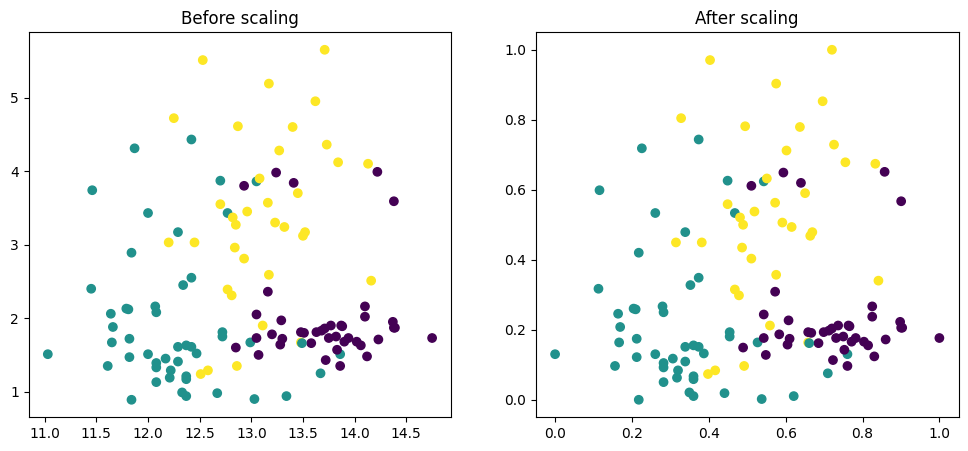

In [39]:
fig, (ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))
ax1.scatter(X_train['Alcohol'],X_train['Malic acid'],c=y_train)
ax1.set_title('Before scaling')
ax2.scatter(X_train_scaled['Alcohol'], X_train_scaled['Malic acid'],c=y_train)
ax2.set_title('After scaling')
plt.show()

In [ ]:
fig, (ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))
ax1.set_title('Before scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)
sns.kdeplot(X_train['Malic acid'], ax=ax1)

ax2.set_title('After standard scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)
sns.kdeplot(X_train_scaled['Malic acid'], ax=ax2